# Lab 5 — Segmentación Médica con nnU-Net (v2)

En este laboratorio aplicaremos nnU-Net (v2), una arquitectura de segmentación médica *self-configuring*, en imágenes de CT abdominal.

El objetivo es segmentar las venas hepáticas a partir de un subconjunto de 5 volúmenes del dataset *Colorectal Liver Metastases (CRLM)*.

**Objetivos:**
1. Comprender el flujo de trabajo de nnU-Net (preprocesamiento → inferencia → visualización).
2. Usar un modelo preentrenado para inferir venas hepáticas.
3. Evaluar y visualizar resultados en 3D y video.

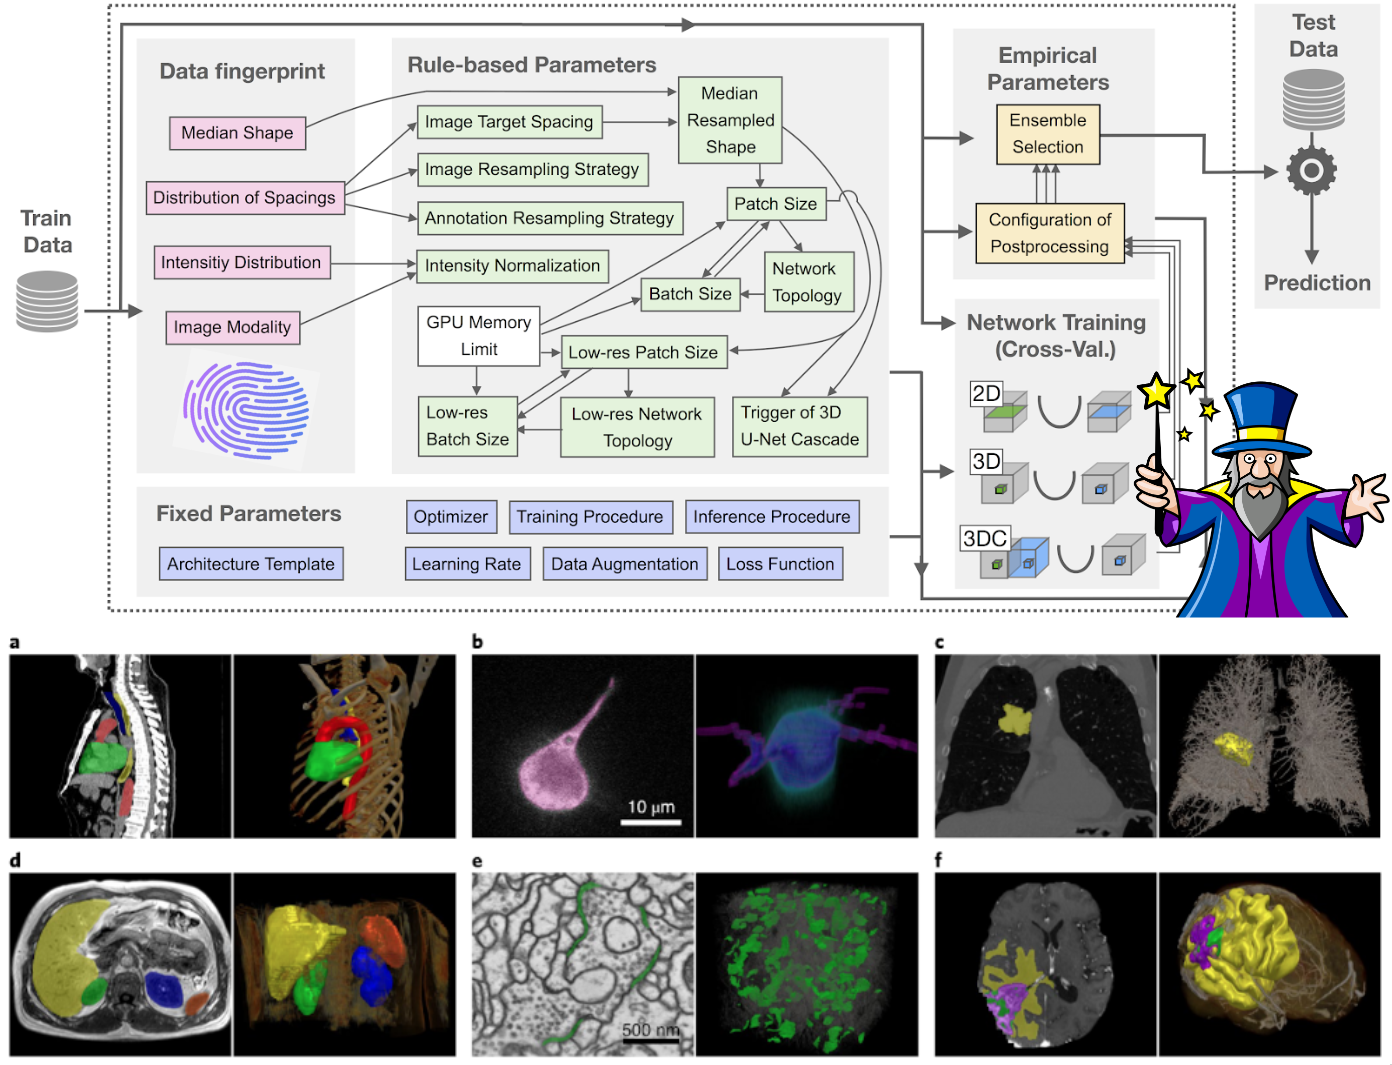

## Setup y dependencias

Instalamos `nnunetv2` del repositorio de github.

In [1]:
!git clone https://github.com/MIC-DKFZ/nnUNet.git
%cd /content/nnUNet
!pip install -q -e .

Cloning into 'nnUNet'...
remote: Enumerating objects: 14005, done.
remote: Total 14005 (delta 0), reused 0 (delta 0), pack-reused 14005 (from 1)
Receiving objects: 100% (14005/14005), 8.60 MiB | 17.83 MiB/s, done.
Resolving deltas: 100% (10703/10703), done.
/content/nnUNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [2]:
import os, json, shutil
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import nibabel as nib
from skimage import measure
import plotly.graph_objects as go
import ipywidgets as widgets
from ipywidgets import VBox
from IPython.display import display

## Variables de entorno y estructura de carpetas

nnU‑Net usa tres rutas:
- `nnUNet_raw` (datasets crudos en formato nnUNet)
- `nnUNet_preprocessed` (datos preprocesados)
- `nnUNet_results` (checkpoints, logs, predicciones)

Crearemos estas carpetas en `/content/nnunet_data`.

In [3]:
BASE = Path('/content/nnunet_data')
RAW = BASE / 'raw'
PRE = BASE / 'preprocessed'
RES = BASE / 'results'
for p in [RAW, PRE, RES]:
    p.mkdir(parents=True, exist_ok=True)
os.environ['nnUNet_raw'] = str(RAW)
os.environ['nnUNet_preprocessed'] = str(PRE)
os.environ['nnUNet_results'] = str(RES)
print('nnUNet_raw =', os.environ['nnUNet_raw'])
print('nnUNet_preprocessed =', os.environ['nnUNet_preprocessed'])
print('nnUNet_results =', os.environ['nnUNet_results'])

nnUNet_raw = /content/nnunet_data/raw
nnUNet_preprocessed = /content/nnunet_data/preprocessed
nnUNet_results = /content/nnunet_data/results


## Descarga de modelos y datos para inferir

Usaremos una parte del dataset [Colorectal-Liver-Metastases](https://www.cancerimagingarchive.net/collection/colorectal-liver-metastases/) que contiene imágenes 3D de tomografía computarizada (CT) de abdomen.

Cada corte o slice de un CT se ve algo así:

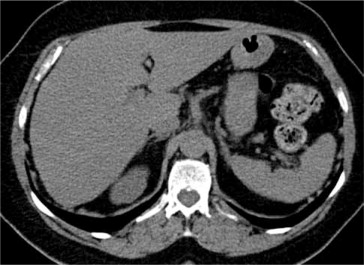

In [4]:
%cd /content
!wget "https://www.dropbox.com/scl/fi/pkhu8wcddyhulvk96cmcg/nnUNet_base.zip?rlkey=vspwlqk7sqq947yl9ss8of1yt&st=lseeu3vv&dl=0" -q -O nnUNet_base.zip
!wget "https://www.dropbox.com/scl/fi/wkhhkt8l3alza2128x89e/CRLM.zip?rlkey=8u22886he17w4tjiga6vfx76p&st=uh2nlel9&dl=0" -q -O CRLM.zip
!unzip CRLM.zip

/content
Archive:  CRLM.zip
   creating: CRLM/
   creating: CRLM/images/
  inflating: CRLM/images/1_0000.nii.gz  
  inflating: CRLM/images/2_0000.nii.gz  
  inflating: CRLM/images/3_0000.nii.gz  
  inflating: CRLM/images/4_0000.nii.gz  
  inflating: CRLM/images/5_0000.nii.gz  
   creating: CRLM/masks/
  inflating: CRLM/masks/1.nii.gz     
  inflating: CRLM/masks/2.nii.gz     
  inflating: CRLM/masks/3.nii.gz     
  inflating: CRLM/masks/4.nii.gz     
  inflating: CRLM/masks/5.nii.gz     


## Instalación del modelo preentrenado

In [5]:
!nnUNetv2_install_pretrained_model_from_zip "/content/nnUNet_base.zip"

## Predicción en 5 casos del dataset

In [6]:
!nnUNetv2_predict -i "/content/CRLM/images" -o "/content/preds" -d 1 -c 3d_custom -f 0 -chk checkpoint_best.pth -tr nnUNetTrainer


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 5 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 5 cases that I would like to predict

Predicting 1:
perform_everything_on_device: True
100% 12/12 [00:17<00:00,  1.43s/it]
sending off prediction to background worker for resampling and export
done with 1

Predicting 2:
perform_everything_on_device: True
100% 6/6 [00:06<00:00,  1.09s/it]
sending off prediction to background worker for resampling and export
done with 2

Predicting 3:
perform_everything_on_device: True
100% 8/8 [00:08<00:00,  1.12s/it]
sending off predi

## Evaluación rápida (Dice) y visualización

Calculamos IoU y Dice y mostramos cortes 2D con GT vs Pred.

Recordatorio:

$$\text{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|} \ \ \ \ \text{Dice}(A,B)=\frac{2|A\cap B|}{|A|+|B|}$$

In [8]:
def iou_and_dice(gt, pr, label=1):
    gt_bin = (gt == label).astype(np.uint8)
    pr_bin = (pr == label).astype(np.uint8)
    inter = (gt_bin & pr_bin).sum()
    union = (gt_bin | pr_bin).sum()
    denom = gt_bin.sum() + pr_bin.sum()
    iou = inter / union if union>0 else 1.0
    dice = (2.0 * inter / denom) if denom>0 else 1.0
    return iou, dice

def load_and_crop_ct(img_path, gt_path, seg_path):
    img = sitk.GetArrayFromImage(sitk.DICOMOrient(sitk.ReadImage(img_path), 'LPS'))
    gt = sitk.GetArrayFromImage(sitk.DICOMOrient(sitk.ReadImage(gt_path), 'LPS'))
    seg = sitk.GetArrayFromImage(sitk.DICOMOrient(sitk.ReadImage(seg_path), 'LPS'))

    z, y, x = np.where(img > 0)
    img = img[z.min():z.max()+1, y.min():y.max()+1, x.min():x.max()+1]
    gt = gt[z.min():z.max()+1, y.min():y.max()+1, x.min():x.max()+1]
    seg = seg[z.min():z.max()+1, y.min():y.max()+1, x.min():x.max()+1]

    img = np.clip(img, 0, 400)
    return img, gt, seg

# normaliza una imagen 2D a [0,1]
def norm01(img2d):
    img2d = img2d.astype(np.float32)
    lo, hi = np.percentile(img2d, 1), np.percentile(img2d, 99)
    denom = (hi - lo) if (hi - lo) > 1e-8 else 1.0
    x = (img2d - lo) / denom
    return np.clip(x, 0, 1)

# overlay binario (mask > 0) sobre una imagen 2D en escala
def overlay(gray2d, mask2d, color=(255, 0, 0), alpha=0.5):
    g = norm01(gray2d)
    base = np.stack([g, g, g], axis=-1)  # (H,W,3)
    m = (mask2d > 0).astype(np.float32)[..., None]
    col = (np.array(color, dtype=np.float32) / 255.0)[None, None, :]
    out = (1 - alpha * m) * base + (alpha * m) * col
    return np.clip(out, 0, 1)

def plot_results_slicer(
    img_id,
    img_root="/content/CRLM/images",
    gt_root="/content/CRLM/masks",
    pred_root="/content/preds",
    ALPHA=0.5
):
    # Cargar volúmenes (usa tu función para mantener orientación/recorte)
    img_path = f"{img_root}/{img_id}_0000.nii.gz"
    gt_path  = f"{gt_root}/{img_id}.nii.gz"
    pr_path  = f"{pred_root}/{img_id}.nii.gz"

    img, gt, pr = load_and_crop_ct(img_path, gt_path, pr_path)  # (Z,Y,X)

    # Métricas volumétricas
    iou, dice = iou_and_dice(gt, pr)

    # Slider de slice
    sld = widgets.IntSlider(value=img.shape[0] // 2, min=0, max=img.shape[0] - 1, step=1, description="Slice")

    out = widgets.Output()

    def _draw(idx):
        with out:
            out.clear_output(wait=True)
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            fig.suptitle(f"{img_id} | slice {idx} | IoU={iou:.4f} · Dice={dice:.4f}", y=1.02)

            # Panel 1: imagen original
            axes[0].imshow(norm01(img[idx]), cmap='gray', origin='lower')
            axes[0].set_title("Imagen")
            axes[0].axis('off')

            # Panel 2: GT overlay (verde)
            axes[1].imshow(overlay(img[idx], gt[idx], color=(0, 255, 0), alpha=ALPHA), origin='lower')
            axes[1].set_title("Ground Truth")
            axes[1].axis('off')

            # Panel 3: Pred overlay (rojo)
            axes[2].imshow(overlay(img[idx], pr[idx], color=(255, 0, 0), alpha=ALPHA), origin='lower')
            axes[2].set_title("Predicción")
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

    # callback
    def _on_change(change):
        if change["name"] == "value":
            _draw(change["new"])

    sld.observe(_on_change, names='value')
    _draw(sld.value)
    display(VBox([sld, out]))

In [11]:
plot_results_slicer(4) # img_id del 1 al 5

## Visualización 3D

In [12]:
def show_gt_pred_3d(img_id,
                    gt_root="/content/CRLM/masks",
                    pred_root="/content/preds",
                    color_gt='green',
                    color_pred='red',
                    opacity=0.35):
    """
    Visualiza GT y Pred simultáneamente con colores distintos.
    """
    gt_path  = f"{gt_root}/{img_id}.nii.gz"
    pred_path  = f"{pred_root}/{img_id}.nii.gz"
    gt = sitk.GetArrayFromImage(sitk.DICOMOrient(sitk.ReadImage(gt_path), "RAS"))
    pred = sitk.GetArrayFromImage(sitk.DICOMOrient(sitk.ReadImage(pred_path), "RAS"))
    gt = (gt>0).astype(np.float32)
    pred = (pred>0).astype(np.float32)

    spacings = [(1.5, 0.8, 0.8),
                (1.5, 0.85, 0.85),
                (5.0, 0.77, 0.77),
                (7.5, 0.70, 0.70),
                (1.5, 0.74, 0.74)]

    # Convierte una máscara binaria (Z,Y,X) en malla (vértices y caras)
    verts_g, faces_g, _, _ = measure.marching_cubes(gt, level=0.5, spacing=spacings[img_id-1], step_size=2)
    verts_p, faces_p, _, _ = measure.marching_cubes(pred, level=0.5, spacing=spacings[img_id-1], step_size=2)

    fig = go.Figure()
    if len(verts_g):
        kg, ig, jg = faces_g.T
        zg, xg, yg = verts_g.T
        fig.add_trace(go.Mesh3d(x=xg,y=yg,z=zg,i=ig,j=jg,k=kg,opacity=opacity,color=color_gt,name='GT'))
    if len(verts_p):
        kp, ip, jp = faces_p.T
        zp, xp, yp = verts_p.T
        fig.add_trace(go.Mesh3d(x=xp,y=yp,z=zp,i=ip,j=jp,k=kp,opacity=opacity,color=color_pred,name='Pred'))

    fig.update_layout(scene=dict(aspectmode='data'), title="GT (verde) vs Pred (rojo)", height=650)
    fig.show()

In [15]:
show_gt_pred_3d(5)

## Extra: Entrenamiento nnUNet
En esta sección dejaré el código para descargar un dataset de segmentación médica, convertirlo a formato nnUNet y preprocesarlo para luego entrenar.

### Descarga de dataset

Medical Segmentation Decathlon fue un challenge organizado para segmentar diversos órganos y estructuras del cuerpo humano. Fue dividido en 10 tareas diferentes con sus respectivos datasets cada una, los cuales se pueden descargar de [aquí](http://medicaldecathlon.com/).

In [5]:
%cd /content
# Ejemplo de descarga del dataset de segmentación de corazón "Task02_Heart"
!wget "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task02_Heart.tar" -O Task02_Heart.tar

# Descomprimir dataset
!tar -xf /content/Task02_Heart.tar

/content
--2025-10-10 13:26:56--  https://msd-for-monai.s3-us-west-2.amazonaws.com/Task02_Heart.tar
Resolving msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)... 52.92.213.42, 52.92.202.34, 3.5.84.162, ...
Connecting to msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)|52.92.213.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 455721472 (435M) [application/x-tar]
Saving to: ‘Task02_Heart.tar’

Task02_Heart.tar    100%[===================>] 434.61M  15.0MB/s    in 36s     

2025-10-10 13:27:32 (12.2 MB/s) - ‘Task02_Heart.tar’ saved [455721472/455721472]



### Conversión a formato nnUNetv2

nnU‑Net espera una estructura DatasetXXX_NAME con subcarpetas `imagesTr/`, `labelsTr/`, `imagesTs/` y un `dataset.json`.

Esta celda toma el Task02_Heart y lo deja como `Dataset002_Heart` en `nnUNet_raw`.

Es importante saber de que modalidad es el dataset (MRI, CT, PET, etc) y si tiene más de una modalidad, las cuales se agregan en `dataset.json` como `"channel_names"`. También es necesario indicar a qué corresponden los valores de los labels, el número de imágenes de entrenamiento y la extensión final de los archivos.

In [6]:
msd_root = Path('/content/Task02_Heart')

dst = Path(os.environ['nnUNet_raw'])/ 'Dataset002_Heart'
for sub in ['imagesTr', 'labelsTr', 'imagesTs']:
    (dst/sub).mkdir(parents=True, exist_ok=True)

# Copiar imágenes entreno/test al formato nnUNet (agregar el canal _0000)
for img in (msd_root/'imagesTr').glob('*.nii.gz'):
    if not img.name.startswith('.'):  # evita archivos ocultos
        shutil.copy(img, dst/'imagesTr'/f"{img.name[:-7]}_0000.nii.gz")
for img in (msd_root/'imagesTs').glob('*.nii.gz'):
    if not img.name.startswith('.'):
        shutil.copy(img, dst/'imagesTs'/f"{img.name[:-7]}_0000.nii.gz")
for lab in (msd_root/'labelsTr').glob('*.nii.gz'):
    if not img.name.startswith('.'):
        shutil.copy(lab, dst/'labelsTr'/lab.name)

# dataset.json mínimo
dataset_json = {
    "channel_names": {  # modalidades
        "0": "MRI",
        },
    "labels": {
        "background": 0,
        "left atrium": 1
        },
    "numTraining": len(list((dst/'imagesTr').glob('*.nii.gz'))),
    "file_ending": ".nii.gz",
    "overwrite_image_reader_writer": "SimpleITKIO" # Esto es opcional
}

with open(dst/'dataset.json', 'w') as f:
    json.dump(dataset_json, f, indent=2)
print('Dataset002_Heart listo en nnUNet_raw')

Dataset002_Heart listo en nnUNet_raw


### Preprocesamiento

Antes de entrenar se tienen que preprocesar los datos en `nnUNet_raw`, indicando el id del dataset (en este caso 2 o 002) y se recomienda usar `--verify_dataset_integrity` para revisar que todos los datos estén correctos y no falten labels o imagénes.

In [7]:
!nnUNetv2_plan_and_preprocess -d 002 --verify_dataset_integrity

Fingerprint extraction...
Dataset002_Heart
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer
100% 20/20 [00:33<00:00,  1.65s/it]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [115. 320. 232.], 3d_lowres: [115, 320, 232]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 40, 'patch_size': (np.int64(320), n

### Entrenamiento

Luego de hacer el preprocesamiento los datos ya están disponibles para ser entrenados. Para esto hay que ocupar el comando

```nnUNetv2_train DATASET_NAME_OR_ID UNET_CONFIGURATION FOLD [additional options, see -h]```

Donde `DATASET_NAME_OR_ID` es el nombre o id del dataset; `UNET_CONFIGURATION` es la configuración de la UNet, la cual puede ser `2d`, `3d_fullres`, `3d_lowres` o `3d_cascade_fullres`; y `FOLD` es el número del fold que se quiere entrenar del 0 al 4 (nnUNet hace cross-validation dividiendo el dataset en 5 folds).

Para más información, revisar la [documentación de nnUNet](https://github.com/MIC-DKFZ/nnUNet/).

In [ ]:
# Ejemplo utilizando el dataset Task02_Heart con una UNet 3D en el fold 0
!nnUNetv2_train 002 3d_fullres 0